In [1]:
from typing import Optional
from torchaudio.datasets import SPEECHCOMMANDS
import torch
import os
import librosa
import torchaudio
from torch import nn
from torchaudio import functional as F
import torch.nn.functional as TF
import matplotlib.pyplot as plt
from thop import profile


In [2]:
SPEECHCOMMANDS(root='dataset', download=True)

Shape of waveform: torch.Size([1, 16000])
Sample rate of waveform: 16000


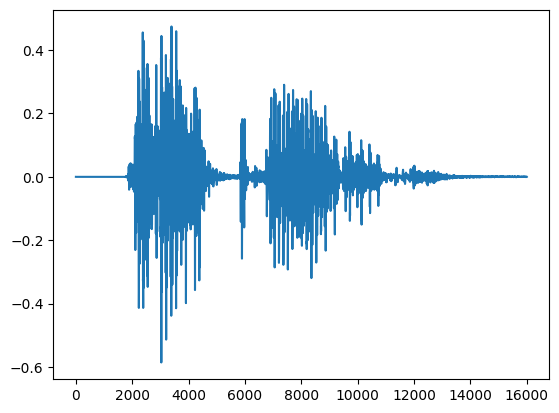

In [3]:
signal, sr = torchaudio.load('dataset/SpeechCommands/speech_commands_v0.02/backward/0a2b400e_nohash_0.wav')
print("Shape of waveform: {}".format(signal.size()))
print("Sample rate of waveform: {}".format(sr))

plt.plot(signal.t().numpy());

In [4]:
import IPython.display as ipd
ipd.Audio(signal.numpy(), rate=sr)

# Layer

In [5]:
class LogMelFilterBanks(nn.Module):
    def __init__(
            self,
            n_fft: int = 400,
            samplerate: int = 16000,
            hop_length: int = 160,
            n_mels: int = 80,
            pad_mode: str = 'reflect',
            power: float = 2.0,
            normalize_stft: bool = False,
            onesided: bool = True,
            center: bool = True,
            return_complex: bool = True,
            f_min_hz: float = 0.0,
            f_max_hz: Optional[float] = None,
            norm_mel: Optional[str] = None,
            mel_scale: str = 'htk'
        ):
        super(LogMelFilterBanks, self).__init__()
        # general params and params defined by the exercise
        self.n_fft = n_fft
        self.samplerate = samplerate
        self.window_length = n_fft
        self.window = torch.hann_window(self.window_length)
        # Do correct initialization of stft params below:
        # hop_length, n_mels, center, return_complex, onesided, normalize_stft, pad_mode, power
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.center =center
        self.return_complex = return_complex
        self.onesided = onesided
        self.normalize_stft = normalize_stft
        self.pad_mode = pad_mode
        self.power = power

        # Do correct initialization of mel fbanks params below:
        # f_min_hz, f_max_hz, norm_mel, mel_scale
        self.f_min_hz  = f_min_hz
        self.f_max_hz  = f_max_hz
        self.norm_mel = norm_mel
        self.mel_scale = mel_scale
        # finish parameters initialization
        self.mel_fbanks = self._init_melscale_fbanks()

    def _init_melscale_fbanks(self):
        # To access attributes, use self.<parameter_name>
        return F.melscale_fbanks(
            # Turns a normal STFT into a mel frequency STFT with triangular filter banks
            # make a full and correct function call
                n_freqs = int(self.n_fft // 2 + 1), 
                f_min = self.f_min_hz, 
                f_max=self.f_max_hz if self.f_max_hz is not None else self.samplerate / 2,
                n_mels = self.n_mels, 
                sample_rate = self.samplerate, 
                norm = self.norm_mel, 
                mel_scale = self.mel_scale
        )

    def spectrogram(self, x):
        # x - is an input signal
        return torch.stft(x,
            n_fft=self.n_fft, 
            win_length=self.window_length, 
            hop_length=self.hop_length,             
            window=self.window, 
            center=self.center, 
            pad_mode=self.pad_mode, 
            normalized=self.normalize_stft, 
            onesided=self.onesided, 
            return_complex=self.return_complex, 
        )

    def forward(self, x):
        """
        Args:
            x (Torch.Tensor): Tensor of audio of dimension (batch, time), audiosignal
        Returns:
            Torch.Tensor: Tensor of log mel filterbanks of dimension (batch, n_mels, n_frames),
                where n_frames is a function of the window_length, hop_length and length of audio
        """
        spec = self.spectrogram(x)      

        spec = spec.abs().pow(self.power)

        mel = torch.einsum("bft,fm->bmt", spec, self.mel_fbanks)
        logmel = torch.log(mel + 1e-6)
        return logmel
        
    def plot_fbank(self, title=None):
        fig, axs = plt.subplots(1, 1)
        axs.set_title("Filter bank")
        axs.imshow(self.mel_fbanks, aspect="auto")
        axs.set_ylabel("frequency bin")
        axs.set_xlabel("mel bin")

    def plot_spectrogram(self, specgram, title="Спектрограмма сигнала"):
        fig, ax = plt.subplots(1, 1)
        ax.set_title(title)
        ax.set_ylabel("freq_bin")
    
        ax.imshow(
            librosa.power_to_db(specgram),
            origin="lower",
            aspect="auto",
            interpolation="nearest",
        )
    
        fig.tight_layout()
        plt.show()

In [6]:
filter_banks = LogMelFilterBanks()

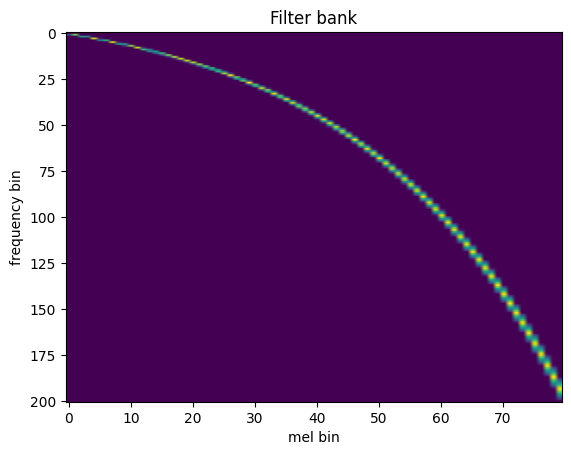

In [7]:
filter_banks.plot_fbank()

In [8]:
spec = filter_banks.spectrogram(signal)
print(f"signal.shape = {tuple(signal.shape)}")  
print(f"spectr.shape = {tuple(spec.shape)}")   

signal.shape = (1, 16000)
spectr.shape = (1, 201, 101)


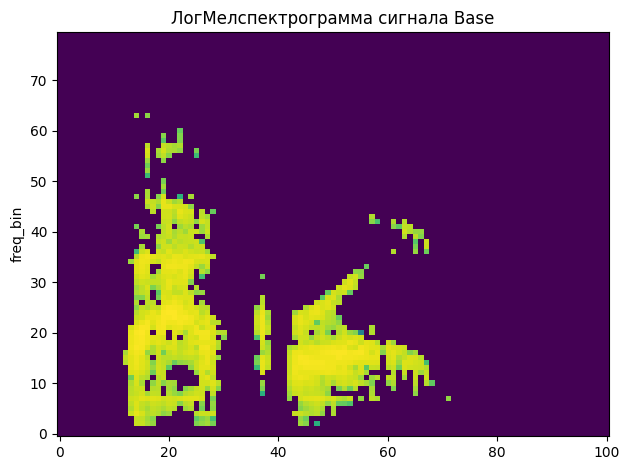

In [9]:
logmelbanks = LogMelFilterBanks()(signal)
filter_banks.plot_spectrogram(logmelbanks[0], title="ЛогМелспектрограмма сигнала Base")

In [10]:
# defolt
melspec = torchaudio.transforms.MelSpectrogram(
    hop_length=160,
    n_mels=80
)(signal)


In [11]:
assert torch.log(melspec + 1e-6).shape == logmelbanks.shape
assert torch.allclose(torch.log(melspec + 1e-6), logmelbanks)

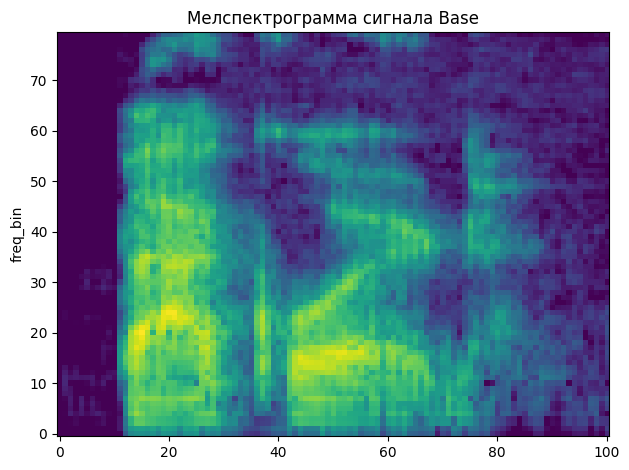

In [12]:
filter_banks.plot_spectrogram(melspec[0], title="Мелспектрограмма сигнала Base")

/tmp/ipykernel_3599/140004873.py:102: UserWarning: power_to_db was called on complex input so phase information will be discarded. To suppress this warning, call power_to_db(np.abs(D)**2) instead.
  librosa.power_to_db(specgram),


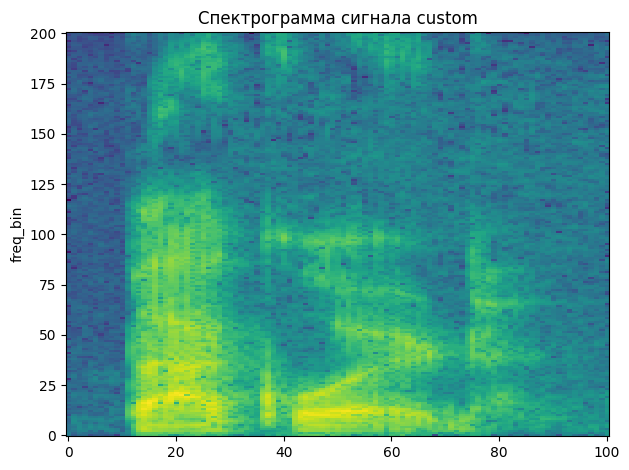

In [13]:
filter_banks.plot_spectrogram(spec[0], title="Спектрограмма сигнала custom")

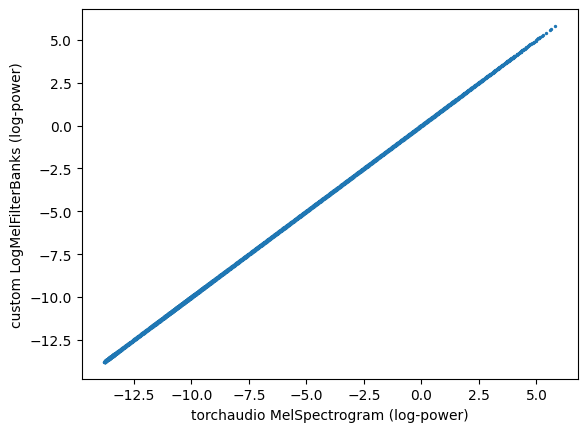

In [14]:
# torchaudio mel-spec 
x = torch.log(melspec.detach().cpu().flatten() + 1e-6)
# кастомный
y = logmelbanks.detach().cpu().flatten()

N = x.numel()
k = min(50_000, N)
idx = torch.randperm(N)[:k]
xs = x[idx]
ys = y[idx]

fig, ax = plt.subplots(1, 1)
ax.set_xlabel("torchaudio MelSpectrogram (log-power)")
ax.set_ylabel("custom LogMelFilterBanks (log-power)")
ax.scatter(xs.numpy(), ys.numpy(), s=2)

ax.plot()

plt.show()

# Dataset

In [15]:
LABELS = [
    "backward","bed","bird","cat","dog","down","eight","five","follow","forward",
    "four","go","happy","house","learn","left","marvin","nine","no","off","on",
    "one","right","seven","sheila","six","stop","three","tree","two","up",
    "visual","wow","yes","zero"
]

In [16]:
class MelDataset(SPEECHCOMMANDS):
    def __init__(self, subset: str = None, root: str = "./dataset", n_mels: int = 80):
        super().__init__(root, subset=subset, download=True)

        self.labels = ["no", "yes"]
        self.label2id = {"no": 0, "yes": 1}

        self.mel = LogMelFilterBanks(n_mels=n_mels)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath, encoding="utf-8") as f:
                return [os.path.normpath(os.path.join(self._path, line.strip())) for line in f]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = set(load_list("validation_list.txt") + load_list("testing_list.txt"))
            self._walker = [w for w in self._walker if w not in excludes]

        self._walker = [w for w in self._walker if "_background_noise_" not in w]
        self._walker = [w for w in self._walker if os.path.basename(os.path.dirname(w)) in ("yes", "no")]

    def _pad_trim_1s(self, wav, sr=16000):
        T = wav.size(-1)
        if T > sr:
            return wav[..., :sr]
        if T < sr:
            return torch.nn.functional.pad(wav, (0, sr - T))
        return wav

    def __getitem__(self, idx):
        waveform, sample_rate, label, *_ = super().__getitem__(idx)

        if waveform.size(0) > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != 16000:
            waveform = torchaudio.functional.resample(waveform, sample_rate, 16000)

        waveform = self._pad_trim_1s(waveform, sr=16000)

        mel = self.mel(waveform)                 # [1, n_mels, T]
        y = torch.tensor(self.label2id[label], dtype=torch.long)  # 0/1
        return mel, y

In [17]:
train_set = MelDataset("training")
val_set = MelDataset("validation")
test_set  = MelDataset("testing")

mel, y = train_set[6149]
print("Shape of mel:", mel.shape)
print("Label id:", int(y))

Shape of mel: torch.Size([1, 80, 101])
Label id: 1


# Model

In [33]:
class MelNet(nn.Module):
    def __init__(self, n_mels=80, n_classes=2, groups=1, ceil_mode=False):
        super().__init__()

        self.conv1 = nn.Conv1d(n_mels, 64, kernel_size=5, stride=1, padding=2, groups=groups)
        self.bn1   = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2, ceil_mode=ceil_mode)

        self.conv2 = nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1, groups=groups)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2, ceil_mode=ceil_mode)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1, groups=groups)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2, ceil_mode=ceil_mode)

        self.head_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        if x.dim() == 4:
            x = x.squeeze(1)

        x = self.pool1(TF.relu(self.bn1(self.conv1(x))))
        x = self.pool2(TF.relu(self.bn2(self.conv2(x))))
        x = self.pool3(TF.relu(self.bn3(self.conv3(x))))

        x = self.head_pool(x).squeeze(-1)
        x = self.fc(x)
        return x

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

    def num_flops(self, input_shape: tuple = (1, 80, 101)):
        device = next(self.parameters()).device
        dummy = torch.zeros(1, *input_shape).to(device)
        flops, _ = profile(self, inputs=(dummy,), verbose=False)
        return int(flops)

In [19]:
from torchsummary import summary
summary(MelNet().cpu(), input_size=(80, 101), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1              [-1, 64, 101]          25,664
       BatchNorm1d-2              [-1, 64, 101]             128
         MaxPool1d-3               [-1, 64, 50]               0
            Conv1d-4               [-1, 64, 50]          12,352
       BatchNorm1d-5               [-1, 64, 50]             128
         MaxPool1d-6               [-1, 64, 25]               0
            Conv1d-7              [-1, 128, 25]          24,704
       BatchNorm1d-8              [-1, 128, 25]             256
         MaxPool1d-9              [-1, 128, 12]               0
AdaptiveAvgPool1d-10               [-1, 128, 1]               0
           Linear-11                    [-1, 2]             258
Total params: 63,490
Trainable params: 63,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/ba

# Train

In [20]:
import lightning as  L
class MelDM(L.LightningDataModule):
    def __init__(self, data_dir: str = "./dataset", batch_size: int = 32, num_workers: int = 0, n_mels: int = 80):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.n_mels = n_mels

    def setup(self, stage: str = None):
        if stage in (None, "fit"):
            self.ds_train = MelDataset("training", root=self.data_dir, n_mels=self.n_mels)
            self.ds_val = MelDataset("validation", root=self.data_dir, n_mels=self.n_mels)

        if stage in (None, "test"):
            self.ds_test = MelDataset("testing", root=self.data_dir, n_mels=self.n_mels)

        if stage in (None, "predict"):
            self.ds_predict = MelDataset("testing", root=self.data_dir, n_mels=self.n_mels)

    def train_dataloader(self):
        return DataLoader(self.ds_train, batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.ds_val, batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.ds_test, batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)

    def predict_dataloader(self):
        return DataLoader(self.ds_predict, batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True)


In [21]:
class MelModul(L.LightningModule):
    def __init__(self, ):
        super().__init__()
        self._model = MelNet()
        self._criterion = nn.CrossEntropyLoss()

        self.train_acc = torchmetrics.classification.Accuracy(task="binary")
        self.val_acc   = torchmetrics.classification.Accuracy(task="binary")
        self.test_acc  = torchmetrics.classification.Accuracy(task="binary")

        self.save_hyperparameters(ignore=["_model"])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self._model(x)
        
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3, weight_decay=1e-4)
    
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )
    
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "valid_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

    def training_step(self, batch, batch_idx) -> torch.Tensor:
        x, y = batch                  
        logits = self(x)               
        loss = self._criterion(logits, y.long())

        preds = logits.argmax(dim=1)    
        self.train_acc(preds, y.int())

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx) -> None:
        x, y = batch
        logits = self(x)
        loss = self._criterion(logits, y.long())

        preds = logits.argmax(dim=1)
        self.val_acc(preds, y.int())

        self.log("valid_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("valid_acc",  self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx) -> None:
        x, y = batch
        logits = self(x)
        loss = self._criterion(logits, y.long())

        preds = logits.argmax(dim=1)
        self.test_acc(preds, y.int())

        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_acc",  self.test_acc, on_step=False, on_epoch=True, prog_bar=True)

In [22]:
import os.path as osp
import torchmetrics
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from torch.utils.data import DataLoader
EXPERIMENTS_PATH  = "experiments"
experiment_name = "exp1"
experiment_save_path = osp.join(EXPERIMENTS_PATH, experiment_name)

datamodule = MelDM()
model = MelModul()
experiment_save_path = "experiments"
os.makedirs(experiment_save_path, exist_ok=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"

In [23]:
logger = TensorBoardLogger(
        save_dir=EXPERIMENTS_PATH,
        name=experiment_name
    )

In [24]:
checkpoint_callback = ModelCheckpoint(
        experiment_save_path,
        monitor="valid_loss",  
        mode="min",
        save_top_k=1,
        save_weights_only=False,
        filename="{epoch:02d}-{valid_loss:.3f}",
    )

In [25]:

trainer = L.Trainer(
        max_epochs=1,
        accelerator=DEVICE,
        devices=1,
        logger=logger,
        callbacks=[
            checkpoint_callback,
            LearningRateMonitor(logging_interval="epoch"),
        ],
        log_every_n_steps=1,
        gradient_clip_val=1.0,
    )



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [26]:
trainer.fit(model=model, datamodule=datamodule)
trainer.test(ckpt_path=checkpoint_callback.best_model_path, datamodule=datamodule)
trainer.validate(
        ckpt_path=checkpoint_callback.best_model_path, datamodule=datamodule
    )
# save_to_torch(model=model, ckpt_path=checkpoint_callback.best_model_path)

You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/venv/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/experiments exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _model     │ MelNet           │ 63.5 K │ train │     0 │
│ 1 │ _criterion │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_acc  │ BinaryAccuracy   │      0 │ train │     0 │
│ 3 │ val_acc    │ BinaryAccuracy   │      0 │ train │     0 │
│ 4 │ test_acc   │ BinaryAccuracy   │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 63.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 63.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/venv/lib/python3.13/site-packages/lightning/pytorch/trai
ner/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve 
performance.

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9854369163513184     │
│         test_loss         │    0.05886698141694069    │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/experiments/epoch=00-valid_loss=0.067.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/manzhura/ITMO/AUDIO/ai-talent-hub-itmo-speech-course/speech/experiments/epoch=00-valid_loss=0.067.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         valid_acc         │    0.9763387441635132     │
│        valid_loss         │    0.06730876117944717    │
└───────────────────────────┴───────────────────────────┘

[{'valid_loss': 0.06730876117944717, 'valid_acc': 0.9763387441635132}]

# Time test

In [34]:
import time
from torch import nn
from thop import profile

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dm = MelDM(batch_size=32)
dm.setup("fit")
train_loader = dm.train_dataloader()
criterion = nn.CrossEntropyLoss()

groups_list = [1, 2, 4, 8, 16]
results = []

for g in groups_list:
    model = MelNet(n_mels=80, groups=g).to(DEVICE) 

    params = model.num_params()
    flops  = model.num_flops(input_shape=(1, 80, 101))

    model.train()
    optimizer = torch.optim.Adam(model.parameters())
    
    x0, y0 = next(iter(train_loader))
    model(x.to(DEVICE))
    torch.cuda.synchronize()
    
    start = time.time()

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE) 
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    torch.cuda.synchronize()  
    epoch_time = time.time() - start

    results.append({
        "groups": g,
        "flops": flops,
        "params": params,
        "epoch_time": round(epoch_time, 3)
    })
    print(f"groups={g} | params={params:,} | flops={flops:,} | time={epoch_time:.2f}s")

groups=1 | params=63,490 | flops=3,867,776 | time=11.43s
groups=2 | params=32,258 | flops=1,960,576 | time=12.15s
groups=4 | params=16,642 | flops=1,006,976 | time=11.74s
groups=8 | params=8,834 | flops=530,176 | time=12.01s
groups=16 | params=4,930 | flops=291,776 | time=11.94s
